In [2]:
import re, os, time, math, tracemalloc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
VOCAB_SIZE = 10000
MAX_LEN = 50
EMBED_DIM = 128
BATCH_SIZE = 16
SEED = 42


In [4]:
def load_wine_reviews():

    df = pd.read_csv("wine_review.csv")
    
    return df["Reviews Text"].astype(str).dropna().tolist()

reviews = load_wine_reviews()
print(len(reviews), "reviews loaded")


2890 reviews loaded


In [5]:
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=MAX_LEN,
)
vectorizer.adapt(reviews)
vocab = vectorizer.get_vocabulary()

sequences = vectorizer(tf.constant(reviews))
print("sequences shape:", sequences.shape)




sequences shape: (2890, 50)


In [6]:
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1.0 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads[None, ...], tf.float32)


In [7]:
def scaled_dot_product_attention(q, k, v, use_scale=True, mask=None):
    scores = tf.matmul(q, k, transpose_b=True)
    if use_scale:
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scores = scores / tf.sqrt(dk)
    if mask is not None:
        scores = scores + (mask * -1e9)
    weights = tf.nn.softmax(scores, axis=-1)
    output = tf.matmul(weights, v)
    return output, weights


In [8]:
class SelfAttentionModel(tf.keras.Model):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=EMBED_DIM, seq_len=MAX_LEN):
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.token_embed = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(seq_len, d_model)
        self.wq = tf.keras.layers.Dense(d_model, use_bias=False)
        self.wk = tf.keras.layers.Dense(d_model, use_bias=False)
        self.wv = tf.keras.layers.Dense(d_model, use_bias=False)

    def call(self, x, use_scale=True, mask=None, return_all=False):
        emb = self.token_embed(x) + self.pos_encoding[:, :tf.shape(x)[1], :]
        q, k, v = self.wq(emb), self.wk(emb), self.wv(emb)
        out, weights = scaled_dot_product_attention(q, k, v, use_scale=use_scale, mask=mask)
        if return_all:
            return emb, q, k, v, out, weights
        return out, weights


In [9]:
model = SelfAttentionModel(d_model=EMBED_DIM, seq_len=MAX_LEN)
sample_batch = sequences[:BATCH_SIZE]
emb, q, k, v, out, weights = model(sample_batch, return_all=True)
print("token embeddings:", emb.shape)
print("Q:", q.shape, "K:", k.shape, "V:", v.shape)
print("attention scores/weights:", weights.shape)
print("attention output:", out.shape)


token embeddings: (16, 50, 128)
Q: (16, 50, 128) K: (16, 50, 128) V: (16, 50, 128)
attention scores/weights: (16, 50, 50)
attention output: (16, 50, 128)


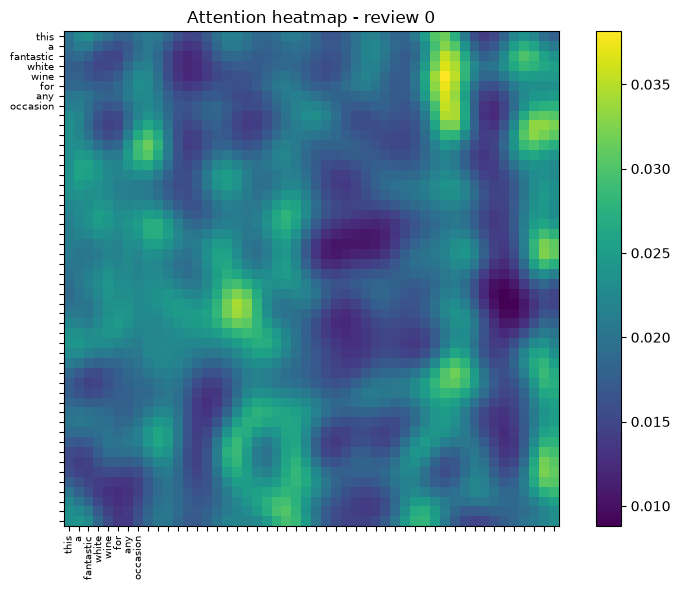

top attended tokens: ['', '', '', '', '']


In [10]:
def plot_attention(weights, tokens, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(weights, cmap="viridis")
    plt.colorbar()
    n = len(tokens)
    plt.xticks(range(n), tokens, rotation=90, fontsize=7)
    plt.yticks(range(n), tokens, fontsize=7)
    plt.title(title)
    plt.tight_layout()
    plt.show()

review_idx = 0
tokens = [vocab[i] for i in sample_batch[review_idx].numpy()]
plot_attention(weights[review_idx, 0].numpy() if weights.ndim == 4 else weights[review_idx].numpy(),
               tokens, "Attention heatmap - review 0")

top_attended = np.argsort(-weights[review_idx].numpy().sum(axis=0))[:5]
print("top attended tokens:", [tokens[i] for i in top_attended])


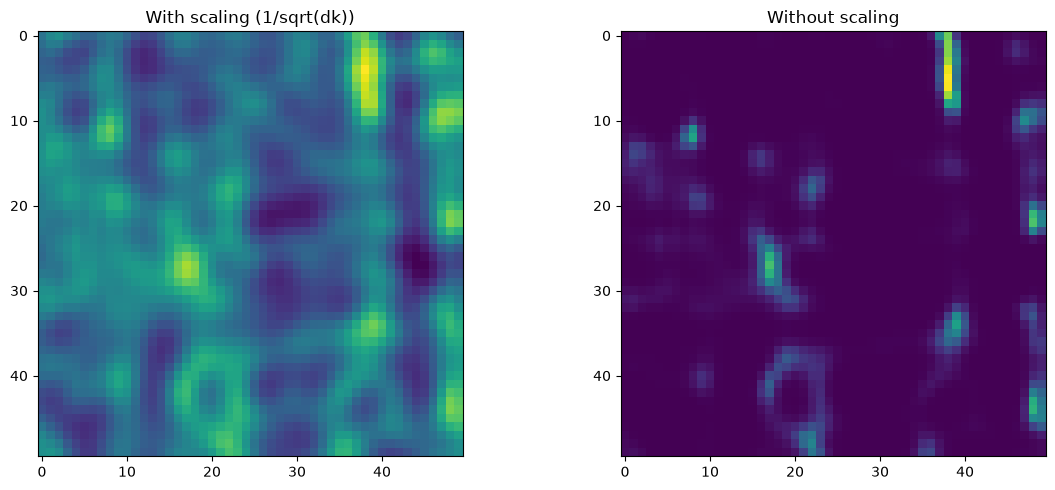

scaled weights std: 0.004405176267027855
unscaled weights std: 0.053799912333488464


In [11]:
_, w_scaled = model(sample_batch, use_scale=True)
_, w_unscaled = model(sample_batch, use_scale=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(w_scaled[review_idx].numpy(), cmap="viridis"); axes[0].set_title("With scaling (1/sqrt(dk))")
axes[1].imshow(w_unscaled[review_idx].numpy(), cmap="viridis"); axes[1].set_title("Without scaling")
plt.tight_layout(); plt.show()

print("scaled weights std:", float(tf.math.reduce_std(w_scaled[review_idx])))
print("unscaled weights std:", float(tf.math.reduce_std(w_unscaled[review_idx])))


embed_dim=64  time=0.0051s  weights shape=(16, 50, 50)
embed_dim=128  time=0.0308s  weights shape=(16, 50, 50)
embed_dim=256  time=0.0264s  weights shape=(16, 50, 50)


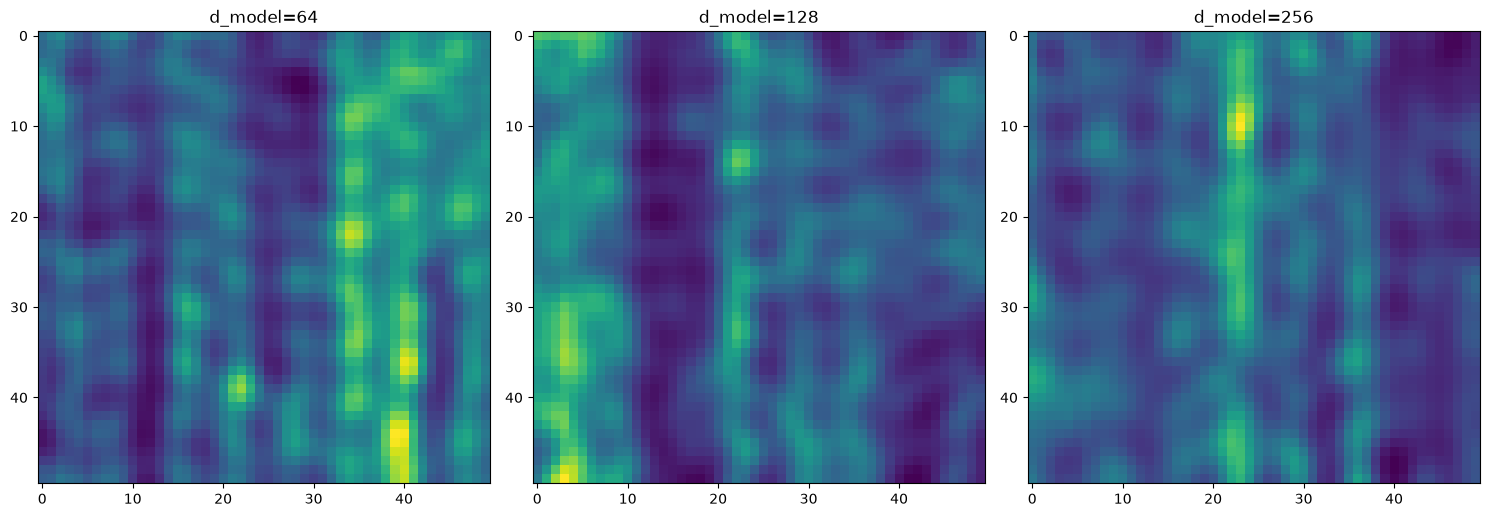

In [12]:
embed_dims = [64, 128, 256]
dim_results = {}
for d in embed_dims:
    m = SelfAttentionModel(d_model=d, seq_len=MAX_LEN)
    start = time.time()
    _, w = m(sample_batch)
    elapsed = time.time() - start
    dim_results[d] = (w.numpy(), elapsed)
    print(f"embed_dim={d}  time={elapsed:.4f}s  weights shape={w.shape}")

fig, axes = plt.subplots(1, len(embed_dims), figsize=(15, 5))
for ax, d in zip(axes, embed_dims):
    ax.imshow(dim_results[d][0][review_idx], cmap="viridis")
    ax.set_title(f"d_model={d}")
plt.tight_layout(); plt.show()


In [13]:
seq_lens = [25, 50, 100]
len_results = {}
for L in seq_lens:
    vec_L = tf.keras.layers.TextVectorization(
        max_tokens=VOCAB_SIZE, standardize="lower_and_strip_punctuation",
        split="whitespace", output_mode="int", output_sequence_length=L)
    vec_L.adapt(reviews)
    seq_L = vec_L(tf.constant(reviews[:BATCH_SIZE]))
    m = SelfAttentionModel(d_model=EMBED_DIM, seq_len=L)
    start = time.time()
    _, w = m(seq_L)
    elapsed = time.time() - start
    len_results[L] = (w.shape, elapsed)
    print(f"seq_len={L}  attn_matrix_shape={w.shape}  time={elapsed:.4f}s")


seq_len=25  attn_matrix_shape=(16, 25, 25)  time=0.0203s
seq_len=50  attn_matrix_shape=(16, 50, 50)  time=0.0285s
seq_len=100  attn_matrix_shape=(16, 100, 100)  time=0.0135s


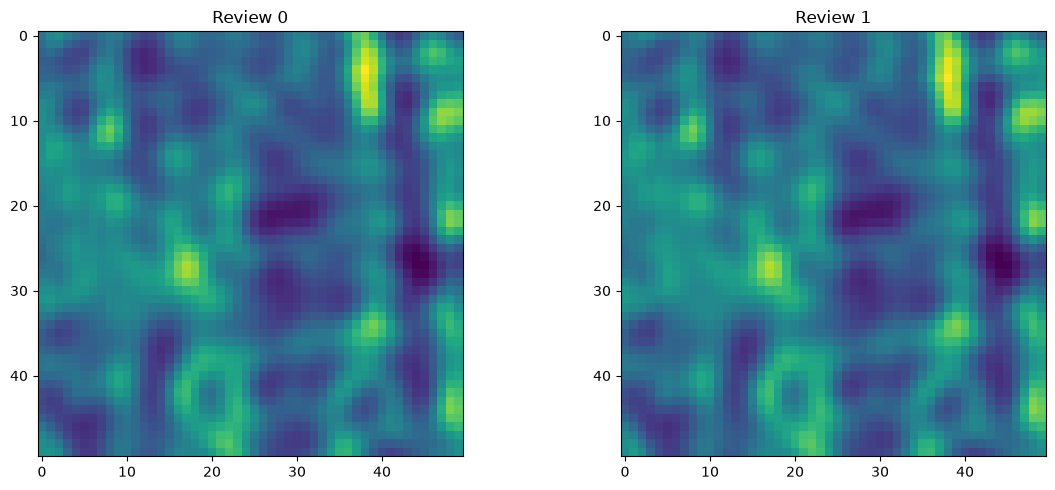

In [14]:
similar_idx = [i for i, r in enumerate(reviews[:200])
               if "cherry" in r.lower() and "oak" in r.lower()][:2]
if len(similar_idx) < 2:
    similar_idx = [0, 1]

selected_sequences = tf.gather(sequences, similar_idx)
_, w_pair = model(selected_sequences)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, idx in enumerate(similar_idx):
    axes[i].imshow(w_pair[i].numpy(), cmap="viridis")
    axes[i].set_title(f"Review {idx}")
plt.tight_layout(); plt.show()


In [15]:
print(f"{'embed_dim':>10} {'seq_len':>8} {'time(s)':>10} {'peak_mem(KB)':>14}")
for d in embed_dims:
    for L in seq_lens:
        vec_L = tf.keras.layers.TextVectorization(
            max_tokens=VOCAB_SIZE, standardize="lower_and_strip_punctuation",
            split="whitespace", output_mode="int", output_sequence_length=L)
        vec_L.adapt(reviews)
        seq_L = vec_L(tf.constant(reviews[:BATCH_SIZE]))
        m = SelfAttentionModel(d_model=d, seq_len=L)
        tracemalloc.start()
        start = time.time()
        _ = m(seq_L)
        elapsed = time.time() - start
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        print(f"{d:>10} {L:>8} {elapsed:>10.4f} {peak / 1024:>14.1f}")


 embed_dim  seq_len    time(s)   peak_mem(KB)
        64       25     0.0231           54.1
        64       50     0.0261           53.2
        64      100     0.0219           53.5
       128       25     0.0165           53.2
       128       50     0.0328           54.8
       128      100     0.0266           54.2
       256       25     0.0159           53.4
       256       50     0.0296           53.6
       256      100     0.0419           53.6


In [16]:
NUM_HEADS = 4
HEAD_DIM = 32

class MultiHeadSelfAttention(tf.keras.layers.Layer):
    def __init__(self, d_model=EMBED_DIM, num_heads=NUM_HEADS, head_dim=HEAD_DIM, use_bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        inner_dim = num_heads * head_dim
        self.wq = tf.keras.layers.Dense(inner_dim, use_bias=use_bias)
        self.wk = tf.keras.layers.Dense(inner_dim, use_bias=use_bias)
        self.wv = tf.keras.layers.Dense(inner_dim, use_bias=use_bias)
        self.wo = tf.keras.layers.Dense(d_model, use_bias=use_bias)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.head_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, x, mask=None):
        batch_size = tf.shape(x)[0]
        q = self.split_heads(self.wq(x), batch_size)
        k = self.split_heads(self.wk(x), batch_size)
        v = self.split_heads(self.wv(x), batch_size)

        out, weights = scaled_dot_product_attention(q, k, v, use_scale=True, mask=mask)

        out = tf.transpose(out, perm=[0, 2, 1, 3])
        out = tf.reshape(out, (batch_size, -1, self.num_heads * self.head_dim))
        return self.wo(out), weights


class MultiHeadModel(tf.keras.Model):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=EMBED_DIM, seq_len=MAX_LEN):
        super().__init__()
        self.token_embed = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(seq_len, d_model)
        self.mha = MultiHeadSelfAttention(d_model, NUM_HEADS, HEAD_DIM)

    def call(self, x, mask=None):
        emb = self.token_embed(x) + self.pos_encoding[:, :tf.shape(x)[1], :]
        return self.mha(emb, mask=mask)

mh_model = MultiHeadModel()
mh_out, mh_weights = mh_model(sample_batch)
print("multi-head output:", mh_out.shape, " weights:", mh_weights.shape)


multi-head output: (16, 50, 128)  weights: (16, 4, 50, 50)


In [17]:
def causal_mask(seq_len):
    mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return mask

mask10 = causal_mask(10)
print(mask10.numpy())


[[0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


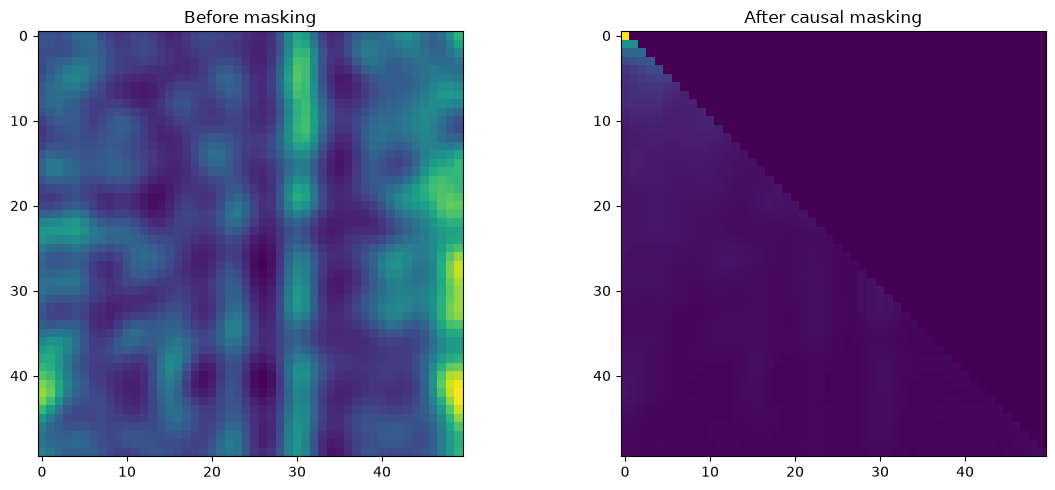

In [18]:
mask_full = causal_mask(MAX_LEN)
out_nomask, w_nomask = mh_model(sample_batch, mask=None)
out_mask, w_mask = mh_model(sample_batch, mask=mask_full)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(w_nomask[review_idx, 0].numpy(), cmap="viridis"); axes[0].set_title("Before masking")
axes[1].imshow(w_mask[review_idx, 0].numpy(), cmap="viridis"); axes[1].set_title("After causal masking")
plt.tight_layout(); plt.show()


In [19]:
future_weights = tf.linalg.band_part(w_mask[review_idx, 0], 0, -1) - tf.linalg.band_part(w_mask[review_idx, 0], 0, 0)
print("max weight on future positions (should be ~0):", float(tf.reduce_max(tf.abs(future_weights))))


max weight on future positions (should be ~0): 0.0


In [20]:
diff = tf.reduce_mean(tf.abs(out_nomask - out_mask))
print("mean abs diff between masked/unmasked contextual outputs:", float(diff))


mean abs diff between masked/unmasked contextual outputs: 0.16082161664962769


In [21]:
start = time.time(); _ = mh_model(sample_batch, mask=None); t_nomask = time.time() - start
start = time.time(); _ = mh_model(sample_batch, mask=mask_full); t_mask = time.time() - start
print(f"time without mask: {t_nomask:.5f}s | time with mask: {t_mask:.5f}s")


time without mask: 0.01034s | time with mask: 0.00579s


In [22]:
GPT_VOCAB_SIZE = 5000
GPT_D_MODEL = 128
GPT_HEADS = 4
GPT_HEAD_DIM = 32
GPT_FFN_DIM = 512
CONTEXT_WINDOW = 64
DROPOUT_RATE = 0.1


In [23]:
class DecoderBlock(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.ln1 = tf.keras.layers.LayerNormalization()
        self.mha = MultiHeadSelfAttention(GPT_D_MODEL, GPT_HEADS, GPT_HEAD_DIM, use_bias=False)
        self.drop1 = tf.keras.layers.Dropout(DROPOUT_RATE)
        self.ln2 = tf.keras.layers.LayerNormalization()
        self.ffn1 = tf.keras.layers.Dense(GPT_FFN_DIM, activation="gelu")
        self.ffn2 = tf.keras.layers.Dense(GPT_D_MODEL)
        self.drop2 = tf.keras.layers.Dropout(DROPOUT_RATE)

    def call(self, x, mask, training=False):
        h = self.ln1(x)
        attn_out, _ = self.mha(h, mask=mask)
        x = x + self.drop1(attn_out, training=training)

        h = self.ln2(x)
        ffn_out = self.ffn2(self.ffn1(h))
        x = x + self.drop2(ffn_out, training=training)
        return x


class MiniGPT(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.token_embed = tf.keras.layers.Embedding(GPT_VOCAB_SIZE, GPT_D_MODEL)
        self.pos_embed = tf.keras.layers.Embedding(CONTEXT_WINDOW, GPT_D_MODEL)
        self.block1 = DecoderBlock()
        self.block2 = DecoderBlock()
        self.final_ln = tf.keras.layers.LayerNormalization()
        self.out_proj = tf.keras.layers.Dense(GPT_VOCAB_SIZE)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        positions = tf.range(seq_len)
        h = self.token_embed(x) + self.pos_embed(positions)[None, :, :]
        mask = causal_mask(seq_len)
        h = self.block1(h, mask, training=training)
        h = self.block2(h, mask, training=training)
        h = self.final_ln(h)
        return self.out_proj(h)

gpt = MiniGPT()
_ = gpt(tf.zeros((1, CONTEXT_WINDOW), dtype=tf.int32))
gpt.summary()



Model: "mini_gpt"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_17 (Embedding)    multiple                  640000    
                                                                 
 embedding_18 (Embedding)    multiple                  8192      
                                                                 
 decoder_block (DecoderBloc  multiple                  197760    
 k)                                                              
                                                                 
 decoder_block_1 (DecoderBl  multiple                  197760    
 ock)                                                            
                                                                 
 layer_normalization_4 (Lay  multiple                  256       
 erNormalization)                                                
                                                         

In [24]:
shakespeare_path = tf.keras.utils.get_file(
    "tinyshakespeare.txt",
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt")
text = open(shakespeare_path, "r").read()

gpt_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=GPT_VOCAB_SIZE, standardize="lower_and_strip_punctuation",
    split="whitespace", output_mode="int")
gpt_vectorizer.adapt([text])
token_ids = gpt_vectorizer([text])[0].numpy()
token_ids = token_ids[token_ids != 0]
print("total tokens:", len(token_ids))


total tokens: 202646


In [25]:
def make_lm_dataset(ids, context_window=CONTEXT_WINDOW, batch_size=32):
    n = (len(ids) - 1) // context_window
    ids = ids[: n * context_window + 1]
    x = np.stack([ids[i:i + context_window] for i in range(0, n * context_window, context_window)])
    y = np.stack([ids[i + 1:i + 1 + context_window] for i in range(0, n * context_window, context_window)])
    ds = tf.data.Dataset.from_tensor_slices((x, y)).shuffle(10000).batch(batch_size, drop_remainder=True)
    return ds.prefetch(tf.data.AUTOTUNE)

lm_ds = make_lm_dataset(token_ids, CONTEXT_WINDOW, batch_size=32)


epoch 1/10  loss=7.8544
epoch 2/10  loss=6.8440
epoch 3/10  loss=6.4341
epoch 4/10  loss=6.3476
epoch 5/10  loss=6.3330
epoch 6/10  loss=6.3072
epoch 7/10  loss=6.2373
epoch 8/10  loss=6.1560
epoch 9/10  loss=6.0676
epoch 10/10  loss=5.9782


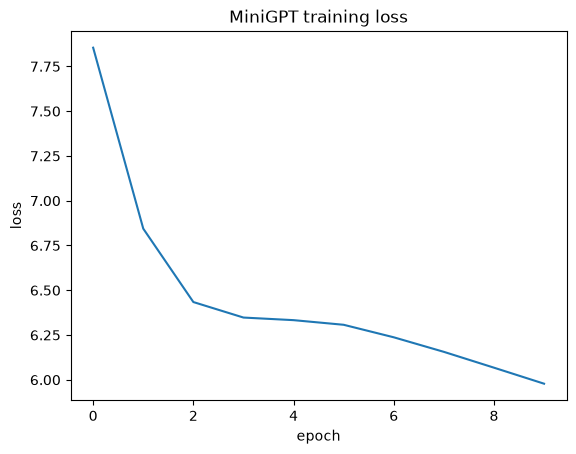

In [26]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
GPT_EPOCHS = 10

@tf.function
def gpt_train_step(x, y):
    with tf.GradientTape() as tape:
        logits = gpt(x, training=True)
        loss = loss_fn(y, logits)
    grads = tape.gradient(loss, gpt.trainable_variables)
    optimizer.apply_gradients(zip(grads, gpt.trainable_variables))
    return loss

gpt_losses = []
for epoch in range(GPT_EPOCHS):
    epoch_losses = []
    for xb, yb in lm_ds:
        epoch_losses.append(float(gpt_train_step(xb, yb)))
    avg = np.mean(epoch_losses)
    gpt_losses.append(avg)
    print(f"epoch {epoch + 1}/{GPT_EPOCHS}  loss={avg:.4f}")

plt.plot(gpt_losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("MiniGPT training loss"); plt.show()


In [27]:
def generate_minigpt(prompt, max_new_tokens=30):
    vocab_gpt = gpt_vectorizer.get_vocabulary()

    # Encode prompt
    ids = gpt_vectorizer([prompt])[0].numpy().tolist()
    ids = [int(x) for x in ids if x != 0]

    # Keep only the context window
    ids = ids[-CONTEXT_WINDOW:]

    for _ in range(max_new_tokens):
        window = ids[-CONTEXT_WINDOW:]

        if len(window) < CONTEXT_WINDOW:
            window = [0] * (CONTEXT_WINDOW - len(window)) + window

        inp = tf.convert_to_tensor(
            [window],
            dtype=tf.int32
        )

        logits = gpt(inp, training=False)

        # Greedy prediction
        next_id = int(
            tf.argmax(logits[0, -1], axis=-1).numpy()
        )

        ids.append(next_id)

    return " ".join(
        vocab_gpt[i]
        for i in ids
        if 0 <= i < len(vocab_gpt) and i != 0
    )

print(generate_minigpt("to be or", max_new_tokens=3))


to be or [UNK] [UNK] [UNK]


In [28]:
from transformers import GPT2Tokenizer, TFGPT2LMHeadModel

gpt2_tok = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_tok.pad_token = gpt2_tok.eos_token
gpt2_model = TFGPT2LMHeadModel.from_pretrained("gpt2")

prompts = ["Artificial Intelligence is", "The future of education"]


c:\Users\Reaper\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFGPT2LMHeadModel.

All the weights of TFGPT2LMHeadModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2LMHeadModel for predictions without further training.


In [29]:
def gpt2_generate(prompt, **gen_kwargs):
    ids = gpt2_tok.encode(prompt, return_tensors="tf")
    out = gpt2_model.generate(ids, pad_token_id=gpt2_tok.eos_token_id, **gen_kwargs)
    return gpt2_tok.decode(out[0], skip_special_tokens=True)

for prompt in prompts:
    for max_len in [30, 60]:
        for temp in [0.7, 1.2]:
            for top_k in [0, 50]:
                text_out = gpt2_generate(prompt, max_length=max_len, do_sample=True,
                                          temperature=temp, top_k=top_k if top_k > 0 else None)
                print(f"[{prompt}] max_len={max_len} temp={temp} top_k={top_k}\n{text_out}\n")


[Artificial Intelligence is] max_len=30 temp=0.7 top_k=0
Artificial Intelligence is adding their own software and hardware to the market. One such software is OpenKey, which mines the signatures of every keystroke on

[Artificial Intelligence is] max_len=30 temp=0.7 top_k=50
Artificial Intelligence is a topic that has been popping up on the internet, and it's hard to ignore the fact that it's one of the most

[Artificial Intelligence is] max_len=30 temp=1.2 top_k=0
Artificial Intelligence is a unique and compelling subject that has taken 6/10 of significant subpar research and 56 individual chromosomes removed from educational animations of the

[Artificial Intelligence is] max_len=30 temp=1.2 top_k=50
Artificial Intelligence is growing faster than any other type of problem in society—if you think about the growing interest in AI, you'll be disappointed,

[Artificial Intelligence is] max_len=60 temp=0.7 top_k=0
Artificial Intelligence is the future of the computer.

WIRED

You are an e

In [30]:
def diversity_score(text):
    words = text.split()
    return len(set(words)) / max(1, len(words))

def repetition_score(text, n=2):
    words = text.split()
    ngrams = [tuple(words[i:i + n]) for i in range(len(words) - n + 1)]
    if not ngrams:
        return 0.0
    return 1 - len(set(ngrams)) / len(ngrams)

strategies = {
    "greedy": dict(max_length=50, do_sample=False, num_beams=1),
    "beam": dict(max_length=50, do_sample=False, num_beams=5, early_stopping=True),
    "top_k": dict(max_length=50, do_sample=True, top_k=50),
    "top_p": dict(max_length=50, do_sample=True, top_p=0.92, top_k=0),
}

for prompt in prompts:
    for name, kwargs in strategies.items():
        text_out = gpt2_generate(prompt, **kwargs)
        print(f"{name:8s} | diversity={diversity_score(text_out):.3f} "
              f"repetition={repetition_score(text_out):.3f}\n{text_out}\n")


greedy   | diversity=0.614 repetition=0.209
Artificial Intelligence is a new field of research that has been gaining traction in recent years. It is a field that has been growing in popularity since the early 1990s.

The field is called Artificial Intelligence and it is a field that has been

beam     | diversity=0.532 repetition=0.348
Artificial Intelligence is one of the most promising areas of research in the field of artificial intelligence. It has been shown to be able to solve many of the most complex problems in the field of artificial intelligence. It has been shown to be able to solve

top_k    | diversity=0.812 repetition=0.000
Artificial Intelligence is a topic that will have to be debated whether or not we have been paying attention to it. When you look at the list of ideas we are talking about here you will notice that you need to go in far back before there is

top_p    | diversity=0.917 repetition=0.000
Artificial Intelligence is not yet taken into account by regulators.

In [31]:
import tensorflow_datasets as tfds

imdb_ds = tfds.load("imdb_reviews", split="train[:2000]", as_supervised=True)
imdb_texts = [t.numpy().decode("utf-8") for t, _ in imdb_ds]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Reaper\tensorflow_datasets\imdb_reviews\plain_text\incomplete.IFRC7P_1.0.0\imdb_reviews-tra…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Reaper\tensorflow_datasets\imdb_reviews\plain_text\incomplete.IFRC7P_1.0.0\imdb_reviews-tes…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Reaper\tensorflow_datasets\imdb_reviews\plain_text\incomplete.IFRC7P_1.0.0\imdb_reviews-uns…

Dataset imdb_reviews downloaded and prepared to C:\Users\Reaper\tensorflow_datasets\imdb_reviews\plain_text\1.0.0. Subsequent calls will reuse this data.


In [32]:
def build_finetune_dataset(texts, tokenizer, block_size=128, batch_size=4):
    all_ids = []
    for t in texts:
        all_ids.extend(tokenizer.encode(t) + [tokenizer.eos_token_id])
    n = (len(all_ids) - 1) // block_size
    all_ids = all_ids[: n * block_size + 1]
    x = np.array([all_ids[i:i + block_size] for i in range(0, n * block_size, block_size)])
    y = np.array([all_ids[i + 1:i + 1 + block_size] for i in range(0, n * block_size, block_size)])
    ds = tf.data.Dataset.from_tensor_slices((x, y)).shuffle(1000).batch(batch_size)
    return ds.prefetch(tf.data.AUTOTUNE)

finetune_ds = build_finetune_dataset(imdb_texts, gpt2_tok)


Token indices sequence length is longer than the specified maximum sequence length for this model (1057 > 1024). Running this sequence through the model will result in indexing errors


In [33]:
def perplexity(model, tokenizer, text):
    ids = tokenizer.encode(text, return_tensors="tf")
    logits = model(ids, training=False).logits
    labels = ids[:, 1:]
    logits = logits[:, :-1, :]
    loss = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
    return float(tf.exp(tf.reduce_mean(loss)))


In [34]:
def finetune_and_compare(model_name, texts_ds, prompts, epochs=1):
    tok = GPT2Tokenizer.from_pretrained(model_name)
    tok.pad_token = tok.eos_token
    model = TFGPT2LMHeadModel.from_pretrained(model_name)

    before = {p: gpt2_generate(p, max_length=40, do_sample=True, top_k=50) for p in prompts}
    ppl_before = {p: perplexity(model, tok, p) for p in prompts}

    optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    @tf.function
    def step(x, y):
        with tf.GradientTape() as tape:
            logits = model(x, training=True).logits
            loss = loss_fn(y, logits)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    for epoch in range(epochs):
        for xb, yb in texts_ds:
            step(xb, yb)

    after = {}
    inf_times, mem_peaks = {}, {}
    for p in prompts:
        tracemalloc.start()
        start = time.time()
        ids = tok.encode(p, return_tensors="tf")
        out = model.generate(ids, max_length=40, do_sample=True, top_k=50,
                              pad_token_id=tok.eos_token_id)
        inf_times[p] = time.time() - start
        _, peak = tracemalloc.get_traced_memory()
        mem_peaks[p] = peak / 1024
        tracemalloc.stop()
        after[p] = tok.decode(out[0], skip_special_tokens=True)

    ppl_after = {p: perplexity(model, tok, p) for p in prompts}

    print(f"=== {model_name} ===")
    for p in prompts:
        print(f"prompt: {p}")
        print("before:", before[p])
        print("after :", after[p])
        print(f"perplexity before={ppl_before[p]:.2f} after={ppl_after[p]:.2f}")
        print(f"inference time={inf_times[p]:.3f}s peak_mem={mem_peaks[p]:.1f}KB")
    return model, tok


for model_name in ["distilgpt2", "gpt2", "gpt2-medium"]:
    finetune_and_compare(model_name, finetune_ds, prompts, epochs=1)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFGPT2LMHeadModel.

All the weights of TFGPT2LMHeadModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2LMHeadModel for predictions without further training.


=== gpt2-medium ===
prompt: Artificial Intelligence is
before: Artificial Intelligence is designed to solve the problems we face while we are still in high school. It provides an amazing tool to improve our brains, while also providing students with the knowledge to develop successful careers
after : Artificial Intelligence is a great achievement. I'd recommend this series, it is a workmanlike effort.
perplexity before=79.34 after=81.29
inference time=13.329s peak_mem=881.1KB
prompt: The future of education
before: The future of education and the economy as we know it for decades, is uncertain," said Charles L. Brown, the White House director of strategic planning. "But, ultimately, we must keep our
after : The future of education was not what it is today, but education is never good enough. In fact, if only there were a few "great" education scientists! <br /><br />The
perplexity before=85.84 after=162.93
inference time=23.441s peak_mem=1131.8KB
